In [1]:
%%bash
pip install transformers==4.30.2
pip install focal_loss_torch
pip install torchmetrics
pip install pymorphy2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 12.2 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 41.7 MB/s eta 0:00:00
Failed to build tokenizers
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.2 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 54.1 MB

  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)


In [26]:
from datasets import load_dataset
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import transforms, datasets,models
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import clear_output
from tqdm import tqdm
import os
import zipfile
import seaborn as sns
import pandas as pd
import numpy as np

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pymorphy2
from nltk.stem.snowball import RussianStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import transformers
import torchmetrics
from torchmetrics.classification import MultilabelF1Score
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from collections import defaultdict
#from gensim.models import Word2Vec
from collections import Counter
from nltk.tokenize import word_tokenize
from transformers import AutoModel, AutoTokenizer
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, classification_report

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
)
from wordcloud import WordCloud, STOPWORDS
from sklearn.preprocessing import LabelEncoder
import warnings
import os
import json
warnings.filterwarnings('ignore')

# Download

In [ ]:
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
df_full = dataset['train'].to_pandas()

In [5]:
# Загрузка индексов
with open('train_idx.txt', 'r') as f:
    train_idx = [int(i.strip()) for i in f.readlines()]
with open('val_idx.txt', 'r') as f:
    val_idx = [int(i.strip()) for i in f.readlines()]
with open('test_idx.txt', 'r') as f:
    test_idx = [int(i.strip()) for i in f.readlines()]

df_train = df_full.iloc[train_idx].copy()
df_val = df_full.iloc[val_idx].copy()
df_test = df_full.iloc[test_idx].copy()


# EDA

In [9]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   56466 non-null  object 
 1   body      61763 non-null  object 
 2   answer    48576 non-null  object 
 3   type      48587 non-null  object 
 4   queue     61765 non-null  object 
 5   priority  61765 non-null  object 
 6   language  61765 non-null  object 
 7   version   28587 non-null  float64
 8   tag_1     48587 non-null  object 
 9   tag_2     48528 non-null  object 
 10  tag_3     48356 non-null  object 
 11  tag_4     43990 non-null  object 
 12  tag_5     27636 non-null  object 
 13  tag_6     13225 non-null  object 
 14  tag_7     5968 non-null   object 
 15  tag_8     2472 non-null   object 
dtypes: float64(1), object(15)
memory usage: 7.5+ MB


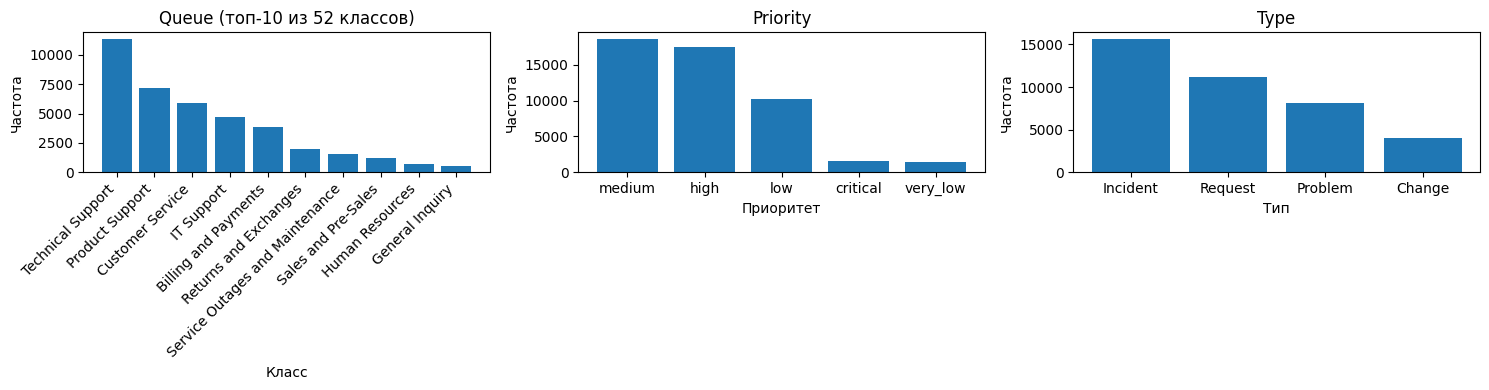

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

queue_counts = df_train['queue'].value_counts().head(10)
axes[0].bar(range(len(queue_counts)), queue_counts.values)
axes[0].set_title(f'Queue (топ-10 из {len(df_train["queue"].unique())} классов)')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Частота')
axes[0].set_xticks(range(len(queue_counts)))
axes[0].set_xticklabels(queue_counts.index, rotation=45, ha='right')


priority_counts = df_train['priority'].value_counts()
axes[1].bar(priority_counts.index, priority_counts.values)
axes[1].set_title('Priority')
axes[1].set_xlabel('Приоритет')
axes[1].set_ylabel('Частота')


type_counts = df_train['type'].value_counts()
axes[2].bar(type_counts.index, type_counts.values)
axes[2].set_title('Type')
axes[2].set_xlabel('Тип')
axes[2].set_ylabel('Частота')

plt.tight_layout()
plt.show()

Дисбаланас классов это полный йоу конечно

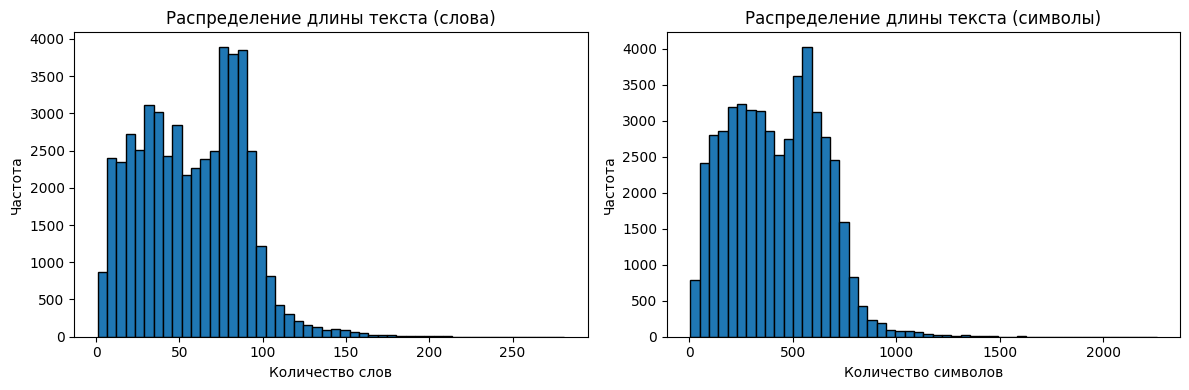


Статистика длины текста:
Слова - среднее: 57.4, медиана: 57
Слова - мин: 1.0, макс: 281.0
Символы - среднее: 419.4, медиана: 415



In [16]:

df_train['word_count'] = df_train['body'].str.split().str.len()
df_train['char_count'] = df_train['body'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_train['word_count'].clip(upper=500), bins=50, edgecolor='black')
axes[0].set_title('Распределение длины текста (слова)')
axes[0].set_xlabel('Количество слов')
axes[0].set_ylabel('Частота')

axes[1].hist(df_train['char_count'].clip(upper=3000), bins=50, edgecolor='black')
axes[1].set_title('Распределение длины текста (символы)')
axes[1].set_xlabel('Количество символов')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

print("\nСтатистика длины текста:")
print(f"Слова - среднее: {df_train['word_count'].mean():.1f}, медиана: {df_train['word_count'].median():.0f}")
print(f"Слова - мин: {df_train['word_count'].min()}, макс: {df_train['word_count'].max()}")
print(f"Символы - среднее: {df_train['char_count'].mean():.1f}, медиана: {df_train['char_count'].median():.0f}")
print()

In [13]:
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

def clean(text, method='lemmer'):
    text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-z\s-]', '', text)
    text = re.sub(r'-', ' ', text)
    if method == 'lemmer':
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(token) for token in text.split()]
    elif method == 'stemmer':
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(token) for token in text.split()]
    else:
        tokens = text.split()

    stop_words_eng = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words_eng and len(token) > 2]
    return ' '.join(tokens)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


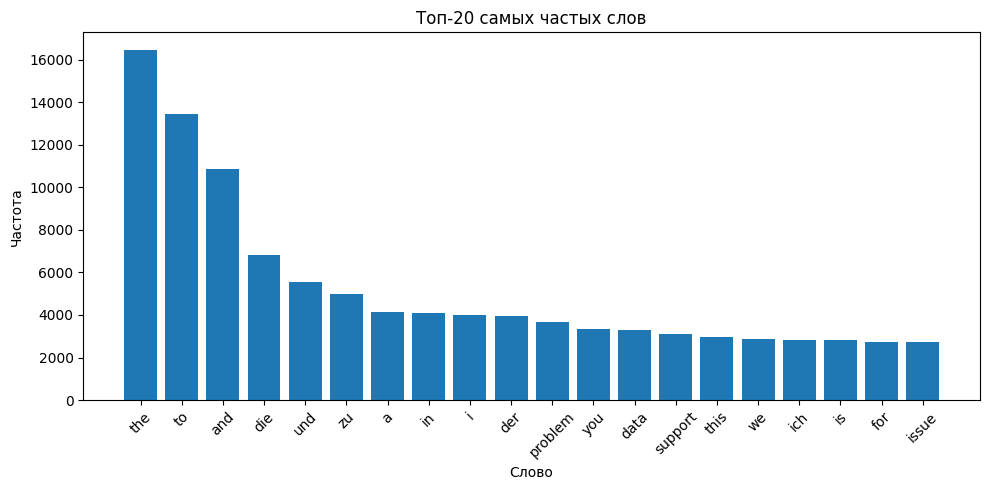


Топ-10 слов:
  the: 16456
  to: 13440
  and: 10841
  die: 6811
  und: 5525
  zu: 4961
  a: 4123
  in: 4104
  i: 3988
  der: 3966

Топ-10 слов после очистки:
  die: 6804
  und: 5525
  problem: 4656
  der: 3962
  issue: 3599
  data: 3278
  system: 2965
  support: 2813
  ich: 2798
  would: 2569



In [25]:
from collections import Counter
import re


all_words = []
all_words_clean = []
for text in df_train.loc[:10000,'body']:
    words = re.findall(r'\b[a-z]+\b', text.lower())
    words_clean = re.findall(r'\b[a-z]+\b', clean(text.lower()))
    all_words.extend(words)
    all_words_clean.extend(words_clean)

word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)

word_freq_clean = Counter(all_words_clean).most_common(20)
words_clean, freqs_clean = zip(*word_freq_clean)

plt.figure(figsize=(10, 5))
plt.bar(words, freqs)
plt.title('Топ-20 самых частых слов')
plt.xlabel('Слово')
plt.ylabel('Частота')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nТоп-10 слов:")
for word, freq in word_freq[:10]:
    print(f"  {word}: {freq}")


print("\nТоп-10 слов после очистки:")
for word_clean, freq_clean in word_freq_clean[:10]:
    print(f"  {word_clean}: {freq_clean}")
print()

судя по топу слов после очистки этому датасету нужно к психологу....

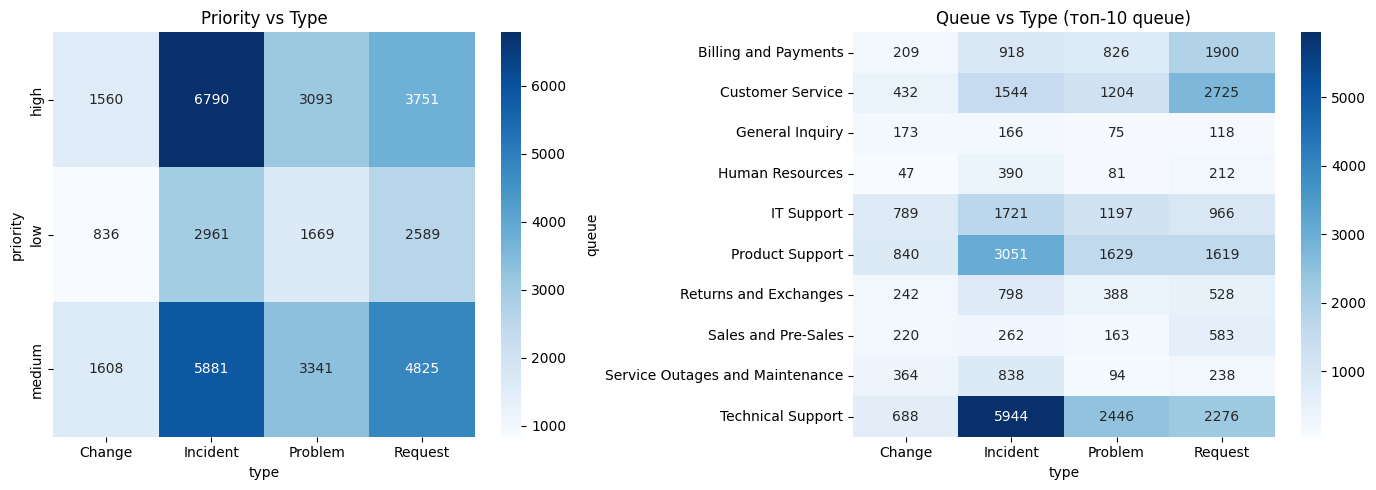

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

priority_type = pd.crosstab(df_train['priority'], df_train['type'])
sns.heatmap(priority_type, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Priority vs Type')

top_queues = df_train['queue'].value_counts().head(10).index
df_top = df_train[df_train['queue'].isin(top_queues)]
queue_type = pd.crosstab(df_top['queue'], df_top['type'])
sns.heatmap(queue_type, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Queue vs Type (топ-10 queue)')
axes[1].set_yticklabels(queue_type.index, rotation=0)

plt.tight_layout()
plt.show()

In [30]:
print("\nДисбаланс классов (queue):")
queue_percentages = (queue_counts / len(df_train) * 100)
print(f"  Самый частый класс: {queue_counts.index[0]} ({queue_counts.values[0]}, {queue_percentages.values[0]:.2f}%)")
print(f"  Самый редкий класс: {df_train['queue'].value_counts().index[-1]} ({df_train['queue'].value_counts().values[-1]}, {df_train['queue'].value_counts().values[-1]/len(df_train)*100:.2f}%)")
print(f"  Топ-5 классов покрывают: {df_train['queue'].value_counts().head(5).sum()/len(df_train)*100:.2f}% данных")
print(f"  Топ-10 классов покрывают: {df_train['queue'].value_counts().head(10).sum()/len(df_train)*100:.2f}% данных")

print("\nПриоритеты:")
for p in priority_counts.index:
    print(f"  {p}: {priority_counts[p]} ({priority_counts[p]/len(df_train)*100:.1f}%)")

print("\nТипы:")
for t in type_counts.index:
    print(f"  {t}: {type_counts[t]} ({type_counts[t]/len(df_train)*100:.1f}%)")



Дисбаланс классов (queue):
  Самый частый класс: Technical Support (11354, 22.98%)
  Самый редкий класс: Real Estate (187, 0.38%)
  Топ-5 классов покрывают: 66.63% данных
  Топ-10 классов покрывают: 78.73% данных

Приоритеты:
  medium: 18629 (37.7%)
  high: 17546 (35.5%)
  low: 10280 (20.8%)
  critical: 1516 (3.1%)
  very_low: 1441 (2.9%)

Типы:
  Incident: 15632 (31.6%)
  Request: 11165 (22.6%)
  Problem: 8103 (16.4%)
  Change: 4004 (8.1%)


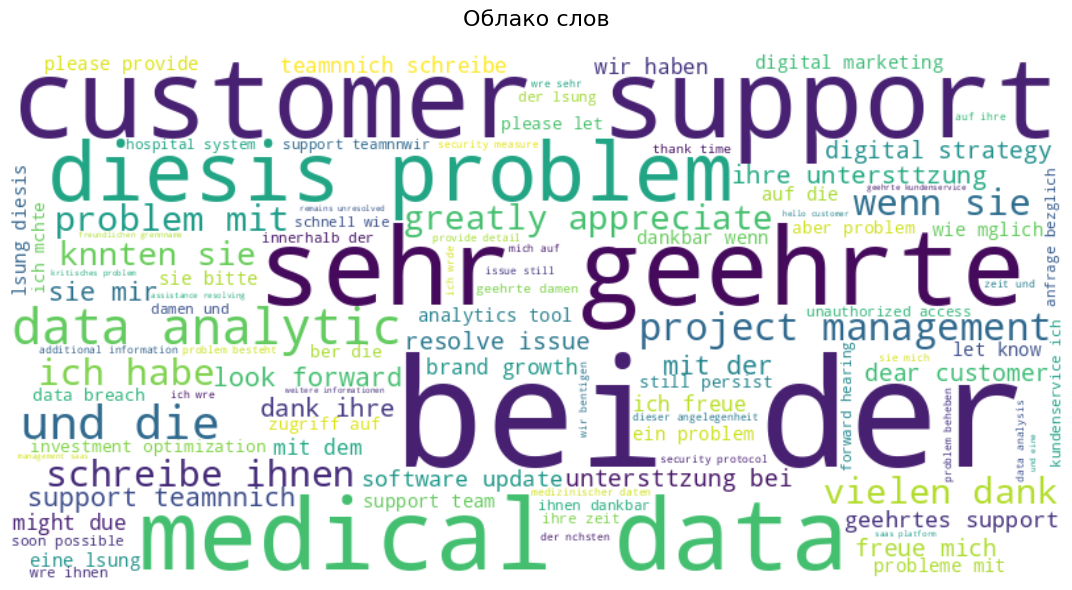

In [46]:

all_text = ' '.join(df_train['text_clean'].astype(str).tolist())


wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    contour_width=1,
    contour_color='steelblue',
    random_state=42
).generate(all_text)


plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# TF-IDF

In [43]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

df_train["type"] = df_train["type"].fillna("Unknown")
df_val["type"] = df_val["type"].fillna("Unknown")
df_test["type"] = df_test["type"].fillna("Unknown")

def text(d):
    return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

X_train = text(df_train)
X_test = text(df_test)

tf_idf = TfidfVectorizer(
    max_features=200_000,
    ngram_range=(1, 2),
    min_df=2,
)
X_train_transf = tf_idf.fit_transform(X_train)
X_test_transf = tf_idf.transform(X_test)

results = {}


for target in ["queue", "priority", "type"]:
    y_train = df_train[target].astype(str).values
    y_test = df_test[target].astype(str).values

    clf = LinearSVC()
    clf.fit(X_train_transf, y_train)
    pred = clf.predict(X_test_transf)

    acc = float(accuracy_score(y_test, pred))
    if target == "queue":
        mf1 = float(f1_score(y_test, pred, average="macro"))
        results["queue_acc"] = acc
        results["queue_macro_f1"] = mf1
        print(f"{target}: acc={acc:.4f}  macro_f1={mf1:.4f}")
    else:
        results[f"{target}_acc"] = acc
        print(f"{target}: acc={acc:.4f}")


score = 0.70 * results["queue_macro_f1"] + 0.15 * results["priority_acc"] + 0.15 * results["type_acc"]
print("\n FINAL SCORE")
print(f"Score = {score:.4f}  (0.70*MacroF1(queue) + 0.15*Acc(priority) + 0.15*Acc(type))")

queue: acc=0.6901  macro_f1=0.8939
priority: acc=0.7112
type: acc=0.8969

 FINAL SCORE
Score = 0.8669  (0.70*MacroF1(queue) + 0.15*Acc(priority) + 0.15*Acc(type))


# Multi-task and fine-tuning

In [7]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
import os
import json
warnings.filterwarnings('ignore')

In [14]:
df_train['text']=df_train["subject"].fillna("") + "\n\n" + df_train["body"].fillna("")
df_val['text']=df_val["subject"].fillna("") + "\n\n" + df_val["body"].fillna("")
df_test['text']=df_test["subject"].fillna("") + "\n\n" + df_test["body"].fillna("")

df_train['text_clean']=df_train.text.apply(lambda x: clean(x))
df_val['text_clean']=df_val.text.apply(lambda x: clean(x))
df_test['text_clean']=df_test.text.apply(lambda x: clean(x))

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

Используется устройство: cuda


In [11]:
encoders = {}
label_mappings = {}

for task in ['queue', 'priority', 'type']:
    le = LabelEncoder()
    le.fit(df_train[task])

    df_train[f'{task}_encoded'] = le.transform(df_train[task])
    df_val[f'{task}_encoded'] = le.transform(df_val[task])
    df_test[f'{task}_encoded'] = le.transform(df_test[task])

    encoders[task] = le
    label_mappings[task] = {
        'classes': le.classes_.tolist(),
        'num_classes': len(le.classes_)
    }

    print(f"{task}: {len(le.classes_)} классов")
    print(f"  Примеры: {le.classes_[:5]}")

with open('label_encoders.json', 'w') as f:
     json.dump(label_mappings, f, indent=2)

queue: 52 классов
  Примеры: ['Arts & Entertainment/Movies' 'Arts & Entertainment/Music'
 'Autos & Vehicles/Maintenance' 'Autos & Vehicles/Sales'
 'Beauty & Fitness/Cosmetics']
priority: 5 классов
  Примеры: ['critical' 'high' 'low' 'medium' 'very_low']
type: 5 классов
  Примеры: ['Change' 'Incident' 'Problem' 'Request' 'Unknown']


In [ ]:
model_name = 'distilbert-base-multilingual-cased'  # тк подходит и для немецкого и для англ
tokenizer = AutoTokenizer.from_pretrained(model_name) #модель для токенизации текста
max_length = 256

### Преобразование в датасеты и даталоадеры

In [17]:
class TicketDataset(Dataset):

    def __init__(self, texts, labels_dict, tokenizer, max_length):
        """
        texts: список текстов
        labels_dict: словарь с метками для каждой задачи
        tokenizer: токенизатор
        max_length: максимальная длина
        """
        self.texts = texts
        self.labels_dict = labels_dict
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        # Токенизация
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        # Извлекаем тензоры
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }

        # Добавляем метки для всех задач
        for task_name, labels in self.labels_dict.items():
            item[f'{task_name}_label'] = torch.tensor(labels[idx], dtype=torch.long)

        return item

In [20]:
train_labels = {
    'queue': df_train['queue_encoded'].values,
    'priority': df_train['priority_encoded'].values,
    'type': df_train['type_encoded'].values
}

val_labels = {
    'queue': df_val['queue_encoded'].values,
    'priority': df_val['priority_encoded'].values,
    'type': df_val['type_encoded'].values
}

test_labels = {
    'queue': df_test['queue_encoded'].values,
    'priority': df_test['priority_encoded'].values,
    'type': df_test['type_encoded'].values
}


train_dataset = TicketDataset(
    df_train['text_clean'].values,
    train_labels,
    tokenizer,
    max_length
)

val_dataset = TicketDataset(
    df_val['text_clean'].values,
    val_labels,
    tokenizer,
    max_length
)

test_dataset = TicketDataset(
    df_test['text_clean'].values,
    test_labels,
    tokenizer,
    max_length
)


batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 3089
Val batches: 386
Test batches: 387


### Построение основной модели (BERT+линейные слои)

In [21]:
class MultiTaskBERT(nn.Module):

    def __init__(self, model_name, num_queue_classes, num_priority_classes, num_type_classes, dropout=0.3):
        super(MultiTaskBERT, self).__init__()


        self.bert = AutoModel.from_pretrained(model_name)
        self.hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)

        # Классификационные головы для каждой задачи
        self.queue_classifier = nn.Linear(self.hidden_size, num_queue_classes)
        self.priority_classifier = nn.Linear(self.hidden_size, num_priority_classes)
        self.type_classifier = nn.Linear(self.hidden_size, num_type_classes)


        self._init_weights()

    def _init_weights(self):
        """Инициализация весов классификаторов"""
        for classifier in [self.queue_classifier, self.priority_classifier, self.type_classifier]:
            nn.init.xavier_uniform_(classifier.weight)
            nn.init.zeros_(classifier.bias)

    def forward(self, input_ids, attention_mask):
        # Прямой проход через BERT
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Берем [CLS] токен (первый токен)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)

        # Предсказания для каждой задачи
        queue_logits = self.queue_classifier(pooled_output)
        priority_logits = self.priority_classifier(pooled_output)
        type_logits = self.type_classifier(pooled_output)

        return {
            'queue': queue_logits,
            'priority': priority_logits,
            'type': type_logits
        }

In [ ]:
num_queue_classes = label_mappings['queue']['num_classes']
num_priority_classes = label_mappings['priority']['num_classes']
num_type_classes = label_mappings['type']['num_classes']

print(f"Количество классов:")
print(f"  Queue: {num_queue_classes}")
print(f"  Priority: {num_priority_classes}")
print(f"  Type: {num_type_classes}")

# Создаем модель
model = MultiTaskBERT(
    model_name=model_name,
    num_queue_classes=num_queue_classes,
    num_priority_classes=num_priority_classes,
    num_type_classes=num_type_classes,
    dropout=0.3
)
model = model.to(device)

In [23]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

Всего параметров: 134,781,758
Обучаемых параметров: 134,781,758


Функции для обучения

In [24]:
def compute_loss(model_output, batch, task_weights):
    losses = {}
    total_loss = 0

    for task, weight in task_weights.items():
        logits = model_output[task]
        labels = batch[f'{task}_label'].to(device)

        # CrossEntropyLoss для каждой задачи
        loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        losses[task] = loss.item()
        total_loss += weight * loss

    return total_loss, losses

def evaluate(model, dataloader, task_weights, return_predictions=False):
    model.eval()

    # Для хранения предсказаний и меток
    all_predictions = {task: [] for task in task_weights.keys()}
    all_labels = {task: [] for task in task_weights.keys()}
    all_probabilities = {task: [] for task in task_weights.keys()}

    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids, attention_mask)

            loss, _ = compute_loss(outputs, batch, task_weights)
            total_loss += loss.item()

            for task in task_weights.keys():
                logits = outputs[task]
                probs = torch.softmax(logits, dim=1)
                preds = torch.argmax(logits, dim=1)

                all_predictions[task].extend(preds.cpu().numpy())
                all_labels[task].extend(batch[f'{task}_label'].cpu().numpy())
                all_probabilities[task].extend(probs.cpu().numpy())

    # Вычисление метрик
    metrics = {}
    for task in task_weights.keys():
        y_true = all_labels[task]
        y_pred = all_predictions[task]

        metrics[f'{task}_acc'] = accuracy_score(y_true, y_pred)
        if task == 'queue':
            metrics[f'{task}_f1'] = f1_score(y_true, y_pred, average='macro')

    metrics['avg_loss'] = total_loss / len(dataloader)

    if return_predictions:
        return metrics, all_predictions, all_labels, all_probabilities
    return metrics

In [27]:
epochs = 10
learning_rate = 2e-5
warmup_steps = int(len(train_loader) * 0.1)
task_weights = {
    'queue': 0.6,
    'priority': 0.2,
    'type': 0.2
}

optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

patience = 3
best_val_f1 = 0
best_epoch = 0
counter = 0

history = {
    'train_loss': [],
    'val_loss': [],
    'val_queue_f1': [],
    'val_queue_acc': [],
    'val_priority_acc': [],
    'val_type_acc': []
}


os.makedirs('models', exist_ok=True) #для зранения лучшей модели

Основной цикл обучения

In [ ]:
for epoch in range(epochs):
    print(f"\n{'='*40}")
    print(f"Эпоха {epoch + 1}/{epochs}")
    print(f"{'='*40}")

    # Training
    model.train()
    train_loss = 0
    train_task_losses = {task: 0 for task in task_weights.keys()}

    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids, attention_mask)

        loss, task_losses = compute_loss(outputs, batch, task_weights)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        # Статистика
        train_loss += loss.item()
        for task, t_loss in task_losses.items():
            train_task_losses[task] += t_loss

        progress_bar.set_postfix({'loss': loss.item()})

    avg_train_loss = train_loss / len(train_loader)

    # Validation
    val_metrics = evaluate(model, val_loader, task_weights)

    # Сохраняем историю
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_metrics['avg_loss'])
    history['val_queue_f1'].append(val_metrics['queue_f1'])
    history['val_queue_acc'].append(val_metrics['queue_acc'])
    history['val_priority_acc'].append(val_metrics['priority_acc'])
    history['val_type_acc'].append(val_metrics['type_acc'])

    # Вывод результатов
    print(f"\nTrain Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {val_metrics['avg_loss']:.4f}")
    print(f"Val Queue Acc: {val_metrics['queue_acc']:.4f}")
    print(f"Val Queue Macro-F1: {val_metrics['queue_f1']:.4f}")
    print(f"Val Priority Acc: {val_metrics['priority_acc']:.4f}")
    print(f"Val Type Acc: {val_metrics['type_acc']:.4f}")

    # Проверка на улучшение
    if val_metrics['queue_f1'] > best_val_f1:
        best_val_f1 = val_metrics['queue_f1']
        best_epoch = epoch + 1

        # Сохраняем лучшую модель
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': best_val_f1,
            'encoders': label_mappings
        }, 'models/best_multitask_model.pt')

        print(f"Новая модель: Macro-F1: {best_val_f1:.4f}")
        counter = 0
    else:
        counter += 1
        print(f"Нет улучшения. Patience: {counter}/{patience}")

        if counter >= patience:
            print(f"\nРанняя остановка на эпохе {epoch + 1}")
            break

print(f"\nОбучение завершено. Лучшая модель на эпохе {best_epoch} с Macro-F1 = {best_val_f1:.4f}")


Эпоха 1/10


Evaluating: 100%|██████████| 386/386 [00:51<00:00,  7.53it/s]



Train Loss: 1.3904
Val Loss: 1.0901
Val Queue Acc: 0.5123
Val Queue Macro-F1: 0.7480
Val Priority Acc: 0.5202
Val Type Acc: 0.8253
Новая модель: Macro-F1: 0.7480

Эпоха 2/10


Evaluating: 100%|██████████| 386/386 [00:51<00:00,  7.53it/s]



Train Loss: 1.0387
Val Loss: 0.9677
Val Queue Acc: 0.5662
Val Queue Macro-F1: 0.8429
Val Priority Acc: 0.5687
Val Type Acc: 0.8491
Новая модель: Macro-F1: 0.8429

Эпоха 3/10


...

Evaluating: 100%|██████████| 386/386 [00:51<00:00,  7.55it/s]



Train Loss: 0.3304
Val Loss: 1.0439
Val Queue Acc: 0.6836
Val Queue Macro-F1: 0.9010
Val Priority Acc: 0.6597
Val Type Acc: 0.8753
Новая модель: Macro-F1: 0.9010

Эпоха 9/10


Evaluating: 100%|██████████| 386/386 [00:51<00:00,  7.56it/s]



Train Loss: 0.2816
Val Loss: 1.0715
Val Queue Acc: 0.6933
Val Queue Macro-F1: 0.9016
Val Priority Acc: 0.6660
Val Type Acc: 0.8768
Новая модель: Macro-F1: 0.9016

Эпоха 10/10


Evaluating:  32%|███▏      | 124/386 [00:16<00:34,  7.60it/s]

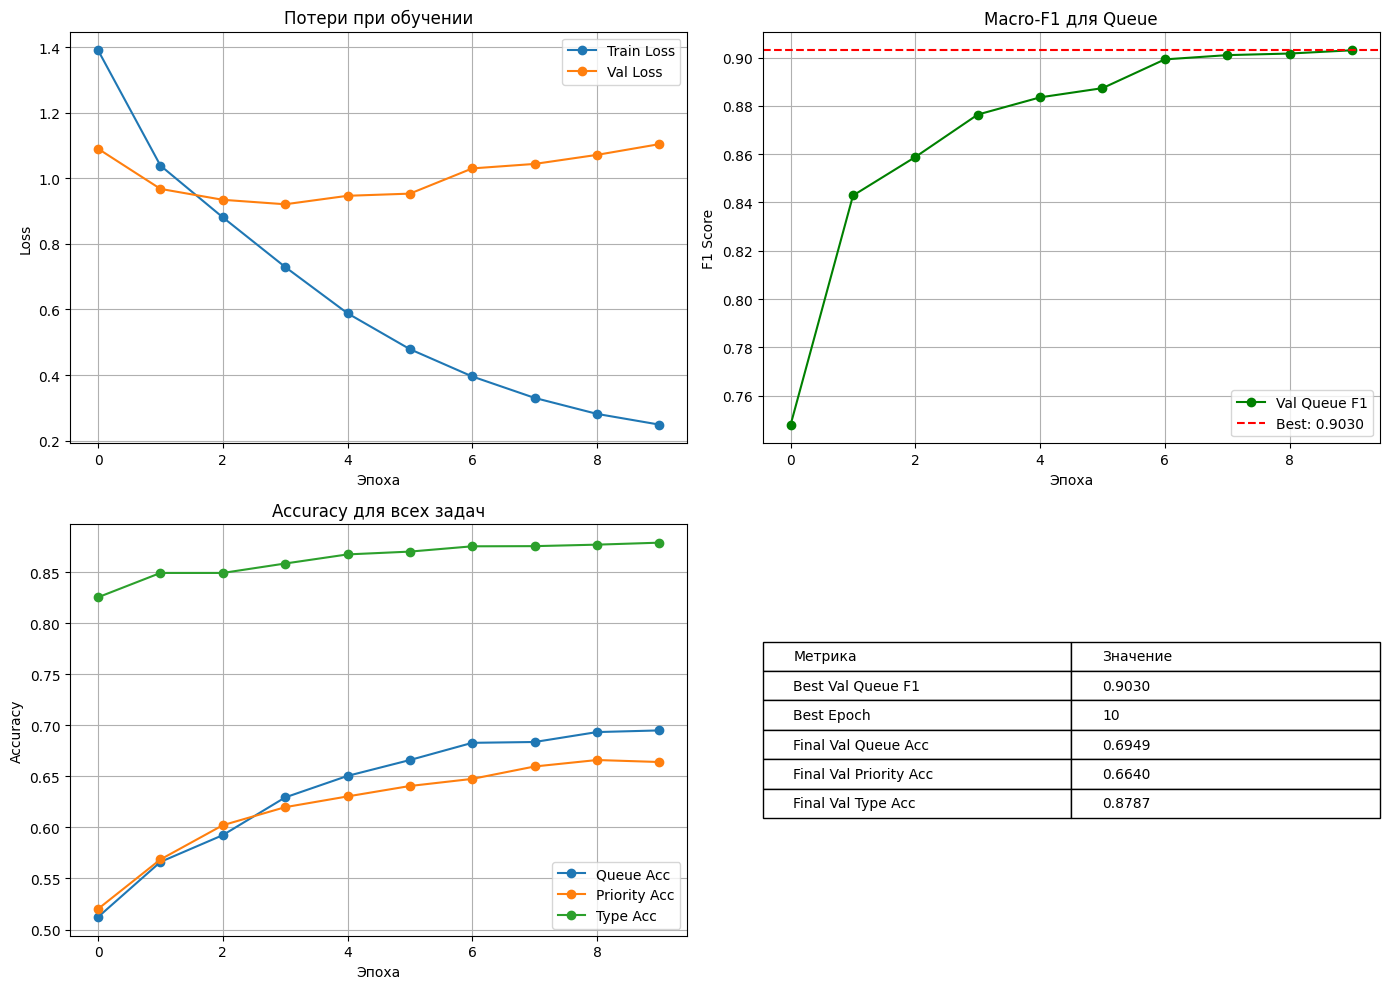

In [35]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График потерь
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0, 0].set_title('Потери при обучении')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# График F1 для queue
axes[0, 1].plot(history['val_queue_f1'], label='Val Queue F1', marker='o', color='green')
axes[0, 1].axhline(y=best_val_f1, color='r', linestyle='--', label=f'Best: {best_val_f1:.4f}')
axes[0, 1].set_title('Macro-F1 для Queue')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].legend()
axes[0, 1].grid(True)

# График accuracy для всех задач
axes[1, 0].plot(history['val_queue_acc'], label='Queue Acc', marker='o')
axes[1, 0].plot(history['val_priority_acc'], label='Priority Acc', marker='o')
axes[1, 0].plot(history['val_type_acc'], label='Type Acc', marker='o')
axes[1, 0].set_title('Accuracy для всех задач')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Сводная таблица метрик
axes[1, 1].axis('off')
metrics_table = [
    ['Метрика', 'Значение'],
    ['Best Val Queue F1', f'{best_val_f1:.4f}'],
    ['Best Epoch', str(best_epoch)],
    ['Final Val Queue Acc', f'{history["val_queue_acc"][-1]:.4f}'],
    ['Final Val Priority Acc', f'{history["val_priority_acc"][-1]:.4f}'],
    ['Final Val Type Acc', f'{history["val_type_acc"][-1]:.4f}']
]
table = axes[1, 1].table(cellText=metrics_table, loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

Можно остановаться на второй эпохе обучения, так как дальше модель начинает переобучаться


In [36]:
epochs=2
for epoch in range(epochs):
    print(f"\n{'='*40}")
    print(f"Эпоха {epoch + 1}/{epochs}")
    print(f"{'='*40}")

    # Training
    model.train()
    train_loss = 0
    train_task_losses = {task: 0 for task in task_weights.keys()}

    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids, attention_mask)

        loss, task_losses = compute_loss(outputs, batch, task_weights)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        # Статистика
        train_loss += loss.item()
        for task, t_loss in task_losses.items():
            train_task_losses[task] += t_loss

        progress_bar.set_postfix({'loss': loss.item()})

    avg_train_loss = train_loss / len(train_loader)

    # Validation
    val_metrics = evaluate(model, val_loader, task_weights)

    # Сохраняем историю
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_metrics['avg_loss'])
    history['val_queue_f1'].append(val_metrics['queue_f1'])
    history['val_queue_acc'].append(val_metrics['queue_acc'])
    history['val_priority_acc'].append(val_metrics['priority_acc'])
    history['val_type_acc'].append(val_metrics['type_acc'])

    # Вывод результатов
    print(f"\nTrain Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {val_metrics['avg_loss']:.4f}")
    print(f"Val Queue Acc: {val_metrics['queue_acc']:.4f}")
    print(f"Val Queue Macro-F1: {val_metrics['queue_f1']:.4f}")
    print(f"Val Priority Acc: {val_metrics['priority_acc']:.4f}")
    print(f"Val Type Acc: {val_metrics['type_acc']:.4f}")

    # Проверка на улучшение
    if val_metrics['queue_f1'] > best_val_f1:
        best_val_f1 = val_metrics['queue_f1']
        best_epoch = epoch + 1

        # Сохраняем лучшую модель
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': best_val_f1,
            'encoders': label_mappings
        }, 'models/best_multitask_model.pt')

        print(f"Новая модель: Macro-F1: {best_val_f1:.4f}")
        counter = 0
    else:
        counter += 1
        print(f"Нет улучшения. Patience: {counter}/{patience}")

        if counter >= patience:
            print(f"\nРанняя остановка на эпохе {epoch + 1}")
            break

print(f"\nОбучение завершено. Лучшая модель на эпохе {best_epoch} с Macro-F1 = {best_val_f1:.4f}")


Эпоха 1/2


Evaluating: 100%|██████████| 386/386 [00:51<00:00,  7.49it/s]



Train Loss: 0.2383
Val Loss: 1.1042
Val Queue Acc: 0.6949
Val Queue Macro-F1: 0.9030
Val Priority Acc: 0.6640
Val Type Acc: 0.8787
Нет улучшения. Patience: 1/3

Эпоха 2/2


Evaluating: 100%|██████████| 386/386 [00:51<00:00,  7.48it/s]


Train Loss: 0.2415
Val Loss: 1.1042
Val Queue Acc: 0.6949
Val Queue Macro-F1: 0.9030
Val Priority Acc: 0.6640
Val Type Acc: 0.8787
Нет улучшения. Patience: 2/3

Обучение завершено. Лучшая модель на эпохе 10 с Macro-F1 = 0.9030


In [37]:
test_metrics, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, task_weights, return_predictions=True
)

print("\nРезультаты на тесте:")
print(f"Queue Accuracy: {test_metrics['queue_acc']:.4f}")
print(f"Queue Macro-F1: {test_metrics['queue_f1']:.4f}")
print(f"Priority Accuracy: {test_metrics['priority_acc']:.4f}")
print(f"Type Accuracy: {test_metrics['type_acc']:.4f}")

# Итоговый Score
final_score = 0.70 * test_metrics['queue_f1'] + \
              0.15 * test_metrics['priority_acc'] + \
              0.15 * test_metrics['type_acc']
print(f"\nИТОГОВЫЙ SCORE: {final_score:.4f}")

Evaluating: 100%|██████████| 387/387 [00:54<00:00,  7.09it/s]


Результаты на тесте:
Queue Accuracy: 0.6895
Queue Macro-F1: 0.8955
Priority Accuracy: 0.6540
Type Accuracy: 0.8706

ИТОГОВЫЙ SCORE: 0.8555


Проводим аналих уверенности\
Берем порого уверенности и считаем для него метрику (часть данных пройдет по порогу, часть отсеится на "ручное определение"). Повторяем процедуру для разных порогов только для целевой queue

In [38]:
confidence = {}
for task in task_weights.keys():
    confidence[task] = np.max(np.array(test_probs[task]), axis=1)

# Основной анализ для queue
queue_confidence = confidence['queue']
queue_preds = np.array(test_preds['queue'])
queue_true = np.array(test_labels['queue'])

# Сортируем по уверенности
sorted_indices = np.argsort(queue_confidence)[::-1]
confidence_sorted = queue_confidence[sorted_indices]
true_sorted = queue_true[sorted_indices]
preds_sorted = queue_preds[sorted_indices]

# Рассчитываем метрики для разных порогов отсечения
thresholds = [1.0, 0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50]
confidence_results = []

print(f"{'Порог':<10} {'% данных':<12} {'Macro-F1':<12} {'Accuracy':<12} {'Ручная работа %':<15}")
print("-" * 65)

for thresh in thresholds:
    mask = queue_confidence >= thresh
    if mask.sum() > 0:
        f1 = f1_score(queue_true[mask], queue_preds[mask], average='macro')
        acc = accuracy_score(queue_true[mask], queue_preds[mask])
        data_percent = mask.sum() / len(queue_true) * 100
        manual_percent = 100 - data_percent

        confidence_results.append({
            'threshold': thresh,
            'data_percent': data_percent,
            'f1': f1,
            'acc': acc,
            'manual_percent': manual_percent
        })

        print(f"{thresh:<10.2f} {data_percent:<12.1f} {f1:<12.4f} {acc:<12.4f} {manual_percent:<15.1f}")


АНАЛИЗ УВЕРЕННОСТИ
Порог      % данных     Macro-F1     Accuracy     Ручная работа %
-----------------------------------------------------------------
0.95       58.2         0.9634       0.8813       41.8           
0.90       65.6         0.9533       0.8428       34.4           
0.85       70.4         0.9455       0.8179       29.6           
0.80       74.6         0.9382       0.8003       25.4           
0.75       78.1         0.9328       0.7868       21.9           
0.70       81.2         0.9288       0.7714       18.8           
0.65       84.0         0.9262       0.7609       16.0           
0.60       87.5         0.9201       0.7446       12.5           
0.55       90.8         0.9138       0.7291       9.2            
0.50       93.7         0.9107       0.7188       6.3            


Лучший результат дается с самым высоким порогом = > наша модель достаточно хороша в оперделении истинных классов

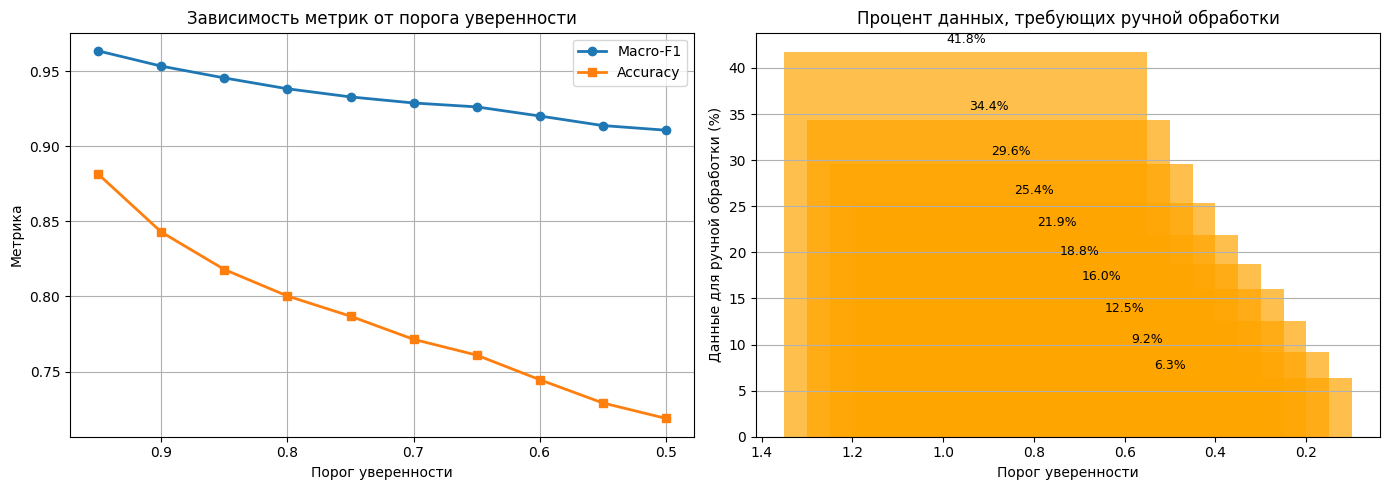

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Зависимость метрик от порога
results_df = pd.DataFrame(confidence_results)

axes[0].plot(results_df['threshold'], results_df['f1'], marker='o', label='Macro-F1', linewidth=2)
axes[0].plot(results_df['threshold'], results_df['acc'], marker='s', label='Accuracy', linewidth=2)
axes[0].set_xlabel('Порог уверенности')
axes[0].set_ylabel('Метрика')
axes[0].set_title('Зависимость метрик от порога уверенности')
axes[0].legend()
axes[0].grid(True)
axes[0].invert_xaxis()  # чтобы порог убывал слева направо

# График 2: Процент данных для ручной обработки
axes[1].bar(results_df['threshold'], results_df['manual_percent'], alpha=0.7, color='orange')
axes[1].set_xlabel('Порог уверенности')
axes[1].set_ylabel('Данные для ручной обработки (%)')
axes[1].set_title('Процент данных, требующих ручной обработки')
axes[1].grid(True, axis='y')
axes[1].invert_xaxis()

# Добавляем значения на столбцы
for i, (thresh, manual) in enumerate(zip(results_df['threshold'], results_df['manual_percent'])):
    axes[1].text(thresh, manual + 1, f'{manual:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('confidence_analysis.png', dpi=150)
plt.show()

In [44]:
baseline_results = {
    'model': 'TF-IDF + LinearSVR',
    'queue_f1': results["queue_macro_f1"],
    'queue_acc': results['queue_acc'],
    'priority_acc': results["priority_acc"],
    'type_acc': results["type_acc"],
    'score': 0.70 * results["queue_macro_f1"] + 0.15 * results["priority_acc"] + 0.15 * results["type_acc"]
}

transformer_results = {
    'model': 'Multi-task BERT',
    'queue_f1': test_metrics['queue_f1'],
    'queue_acc': test_metrics['queue_acc'],
    'priority_acc': test_metrics['priority_acc'],
    'type_acc': test_metrics['type_acc'],
    'score': final_score
}

comparison_df = pd.DataFrame([baseline_results, transformer_results])
print(comparison_df.to_string(index=False))


             model  queue_f1  queue_acc  priority_acc  type_acc    score
TF-IDF + LinearSVR  0.893851   0.690141      0.711187  0.896876 0.866905
   Multi-task BERT  0.895473   0.689493      0.654039  0.870649 0.855534


По итоговому score лучше базовая модель tf-idf, тк метрики accuracy по нему лучше для всех трех целевых переменных, хотя f1 для queue лучше у  Multi-task BERT